In [1]:
%%html
<script>//Needs to be "nbsphinx" : "hidden"
MathJax.Hub.Config({
    TeX: { equationNumbers: {autoNumber: 'AMS'} }});
MathJax.Hub.Queue(
  ["resetEquationNumbers", MathJax.InputJax.TeX],
  ["PreProcess", MathJax.Hub],
  ["Reprocess", MathJax.Hub]
);
</script>

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Due to a Jupyter bug, the %matplotlib inline "magic" command needs to be in 
# its own cell. See:
# https://github.com/jupyter/notebook/issues/3385

%matplotlib inline

In [4]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 16}
matplotlib.rc('font', **font)
matplotlib.rcParams['savefig.dpi'] = 200
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = [7, 3.5]

# Model Fitting Part III - Optimization Techniques


We have seen that in general we will need to maximize a likelihood or a Bayesian posterior.

The likelihood may have a least squares ($\chi^2$) form, or it may be more complicated.

There are two classes of algorithms: those that find a local minimum, and those that attempt to find a global one.

## Finding the _Local_ Minimum

There are several methods for finding the local minimum

### [Nelder-Mead](https://en.wikipedia.org/wiki/Nelder%E2%80%93Mead_method) or Simplex

Reliable but slow, does not need derivatives. A simplex is a an M+1 vertex object in an M dimensional space, e.g. a triangle in 2D, tetrahedron in 3D.

[Simplex](https://upload.wikimedia.org/wikipedia/commons/d/de/Nelder-Mead_Himmelblau.gif)


### Conjugate gradient or Powell's method

Faster for well behaved functions. Does not need derivatives.



A comparison of the convergence of gradient desc|ent with optimal step size (in green) and conjugate vector (in red) for minimizing a quadratic function associated with a given linear system. Conjugate gradient, assuming exact arithmetic, converges in at most $n$ steps, where $n$ is the size of the matrix of the system (here $n = 2$).

### Levenberg-Marquardt

A combination of Gauss-Newton and gradient descent. 

This is the method used by ``scipy.optimize.leastsq`` and ``scipy.optimize.curve_fit``



Many of these algorithms are built into the [lmfit](https://lmfit.github.io/lmfit-py/index.html)
package which is a wrapper around [scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/optimize.html) and [scipy.optimize.leastsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.leastsq.html), which itself is wrapped around the FORTRAN minpack routines.

``lmfit`` has two major ease-of-use advantages:

1. easily set allowed ranges (minima and maxima) for individual parameters
2. easily freeze a parameter or allow it to vary


Let's simulate the detection of a line above a constant background (could be an emission line in a galaxy spectrum, or the Higgs boson)

The line will have a number of counts, a position and a width but its shape will be assumed to be Gaussian.

In [27]:
import numpy.random
import scipy.stats

def gendata(n,frac,pos,width):

    # make some fake uniform data
    duniform = numpy.random.rand(int((1.-frac)*n))
    #print(len(duniform))

    rv = scipy.stats.norm(loc=pos, scale=width)
    dline = rv.rvs(int(frac*n))
    #print(len(dline))
               
    data = np.hstack((duniform,dline))
    return data

If we had amazing data the results might look like this:

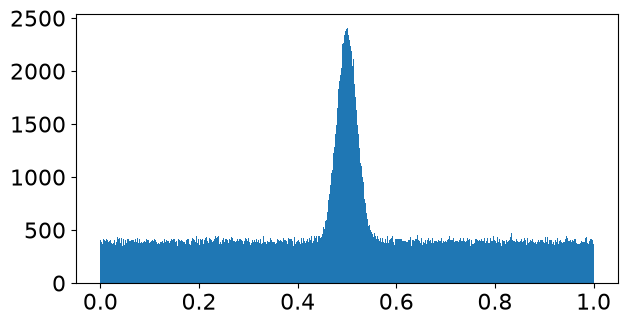

In [28]:
n = 500_000
frac = 0.2
pos = 0.5
width= 0.02
data= gendata(n,frac,pos,width)

counts, edges, patches = plt.hist(data, bins=1000)

More often we have poorer data and have to deal with something like this:

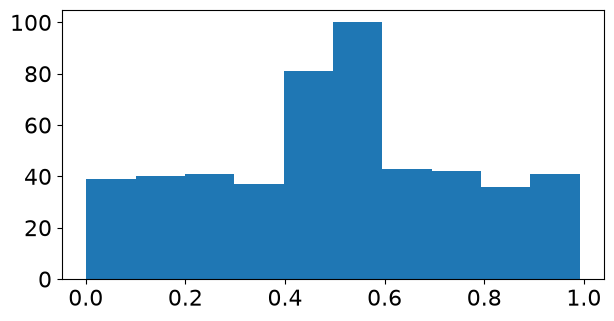

In [29]:
n = 500
frac = 0.2
pos = 0.5
width= 0.02
data= gendata(n,frac,pos,width)

counts, edges, patches = plt.hist(data)

Note: for the rest of this notebook and the next you may need to install some non-standard packages:

```
conda install -c conda-forge lmfit
conda install -c conda-forge emcee
conda install -c conda-forge corner
```


In [30]:
import lmfit

params = lmfit.Parameters()
params.add('frac', value=0.3, min=0., max=1.0)
params.add('pos', value=0.6, min=0.2, max=0.8)
params.add('width', value=0.2, min=1.e-6, max=0.3)
params

name,value,initial value,min,max,vary
frac,0.30000000,0.3,0.00000000,1.00000000,True
pos,0.60000000,0.6,0.20000000,0.80000000,True
width,0.20000000,0.2,1.0000e-06,0.30000000,True


In [31]:
params.pretty_print()

Name      Value      Min      Max   Stderr     Vary     Expr Brute_Step
frac        0.3        0        1     None     True     None     None
pos         0.6      0.2      0.8     None     True     None     None
width       0.2    1e-06      0.3     None     True     None     None


In [32]:
import scipy.stats
# A fitting function for the histogram

def residual(params, counts, edges):

    ntot = np.sum(counts)

    # unpack parameters: extract .value attribute for each parameter
    val = params.valuesdict()
    mean = val['pos']
    std = val['width']
    rv = scipy.stats.norm(mean, std)
    linecounts = (rv.cdf(edges[1:]) - rv.cdf(edges[:-1])) * val['frac'] * ntot

    fracbinwidths = (edges[1:] - edges[:-1]) / (edges[-1] - edges[0])
    bkgdcounts = (1. - val['frac']) * ntot * fracbinwidths

    model = bkgdcounts + linecounts

    # Return the residual, normalized by the uncertainties
    # For a Poisson distribution, the mean and variance are the same
    return (counts - model) / np.sqrt(model)

In [33]:
fitter = lmfit.Minimizer(residual, params, fcn_args=(counts, edges))
result = fitter.minimize(method='nelder-mead')

# result is a MinimizerResult object. It has several useful data/methods
result.params.pretty_print()


Name      Value      Min      Max   Stderr     Vary     Expr Brute_Step
frac       0.21        0        1     None     True     None     None
pos      0.5078      0.2      0.8     None     True     None     None
width   0.04434    1e-06      0.3     None     True     None     None


Notice that there are no uncertainties.

In ``lmfit`` only the ``leastsq`` method yields uncertainties. 

So once you have found the minimum by any method, rerun starting from there but using ``leastsq`` 

In [34]:
result = lmfit.minimize(residual, params, args=((counts, edges)), method='leastsq') 
# leastsq is Levenberg-Marquardt

print(result.nfev, "function evaluations")
result.params.pretty_print()
print("Chi^2:", result.chisqr, "AIC:", result.aic, "BIC:", result.bic)

41 function evaluations
Name      Value      Min      Max   Stderr     Vary     Expr Brute_Step
frac       0.21        0        1  0.01222     True     None     None
pos      0.5078      0.2      0.8 0.003472     True     None     None
width   0.04434    1e-06      0.3  0.00755     True     None     None
Chi^2: 0.8686844956033538 AIC: -18.43360378684301 BIC: -17.52584850786087


In [35]:
print(result.covar)

[[1.49224531e-04 1.40221306e-05 5.53555050e-05]
 [1.40221306e-05 1.20561041e-05 1.56208687e-05]
 [5.53555050e-05 1.56208687e-05 5.69962355e-05]]


Another way to print results and correlation matrix

In [36]:
print(lmfit.fit_report(result.params))

[[Variables]]
    frac:   0.21001464 +/- 0.01221575 (5.82%) (init = 0.3)
    pos:    0.50780428 +/- 0.00347219 (0.68%) (init = 0.6)
    width:  0.04433592 +/- 0.00754959 (17.03%) (init = 0.2)
[[Correlations]] (unreported correlations are < 0.100)
    C(frac, width) = +0.6002
    C(pos, width)  = +0.5959
    C(frac, pos)   = +0.3306


Now suppose we wanted to fix a parameter to some value. With ``scipy.optimize.curve_fit``, you would have to rewrite a whole lot of code. 

It's a lot easier with `lmfit`

In [37]:
# Fix the parameter pos=0.5
params['pos'].value = 0.5
params['pos'].vary = False

fitter = lmfit.Minimizer(residual, params, fcn_args=(counts, edges))
result = fitter.minimize(method='leastsq')
print(result.nfev)
result.params.pretty_print()
print("Chi^2:", result.chisqr, "AIC:", result.aic, "BIC:", result.bic)

26
Name      Value      Min      Max   Stderr     Vary     Expr Brute_Step
frac      0.202        0        1  0.00961     True     None     None
pos         0.5      0.2      0.8        0    False     None     None
width   0.01562    1e-06      0.3 0.004034     True     None     None
Chi^2: 1.0247807328254877 AIC: -18.781064224822952 BIC: -18.175894038834862


The fit is working, but is not finding the correct result for the width due to the binning


In [38]:
# This is the log-likelihood probability for the sampling.

def prob(data, frac, pos, width):

    froznorm = scipy.stats.norm(loc=pos, scale=width)
    pgauss = frac*froznorm.pdf(data)

    xrange = 1.
    puniform = (1.-frac)/xrange
    prob = puniform + pgauss 
    # note model is automatically normalized
    return prob

def lnprob(param, data):
    vals = param.valuesdict()
    probs = prob(data, vals['frac'], vals['pos'], vals['width'])

    return np.sum(np.log(probs))

def lnprob_arr(arr, data):
    probs = prob(data, arr[0], arr[1], arr[2])
    
    return np.sum(np.log(probs))

In [39]:
import scipy.integrate

print(frac,pos,width)
integ, err = scipy.integrate.quad(prob, 0., 1., args=(frac,pos,width))
print(integ)

0.2 0.5 0.02
1.0


In [40]:
# Note the keyword argument fcn_args
params['frac'].value=0.5
params['pos'].value=0.6
params['pos'].vary = True
params['width'].value=0.2

In [41]:
# for a scalar cost function we will minimize
# so we need the function to be negative
nll = lambda *args: -lnprob(*args)
minim = lmfit.Minimizer(nll, params, fcn_args=((data,)))

result = minim.scalar_minimize(method='Nelder-Mead')
lmfit.printfuncs.report_fit(result.params, min_correl=0.01)


[[Variables]]
    frac:   0.18918525 (init = 0.5)
    pos:    0.50074946 (init = 0.6)
    width:  0.01762356 (init = 0.2)


The problem with this method is that it doesn't measure uncertainties (at least not yet in ``lmfit``, but should work with [``scipy.optimize.curve_fit``](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html))

An alternative is to use Monte-Carlo Markov Chains, or MCMC. We will describe how these in more detail work later. 

In [42]:
def plotchains(chain, labels=None):
    shape = chain.shape
    (nsteps, nwalkers, npars) = list(shape)
    print("Chain shape: ", nsteps, "steps,", nwalkers, "walkers,", npars, "params." )
    for npar in range(npars):
        # start a new plot
        fig, ax = plt.subplots()
        for nwalk in range(nwalkers):
            plt.plot(range(nsteps), chain[:,nwalk,npar], lw=0.7)
        if labels:
            plt.xlabel('Steps')
            plt.ylabel(labels[npar])
                

In [43]:
# for emcee, we *maximise*, so the function is just ln(posterior)
minim = lmfit.Minimizer(lnprob, params, fcn_args=((data,)),float_behavior='posterior')
emcee_result = minim.emcee(burn=0, steps=500, thin=1, params=minim.params)

100%|██████████████████████████████████████████| 500/500 [00:08<00:00, 59.67it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 10;
tau: [51.39495574 39.90112667 49.3648195 ]


Each line in the following plot represents a chain of parameters

Chain shape:  500 steps, 100 walkers, 3 params.


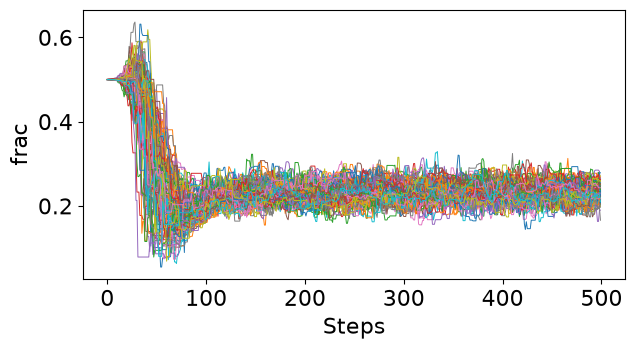

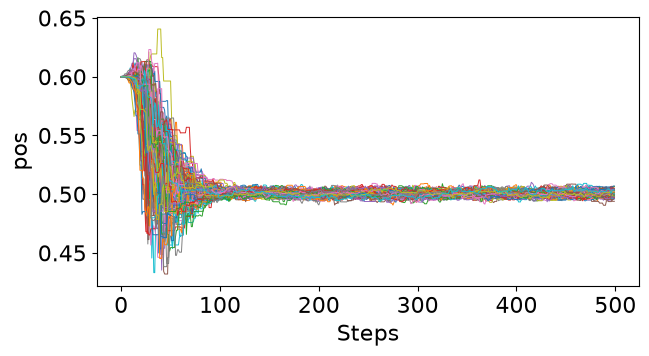

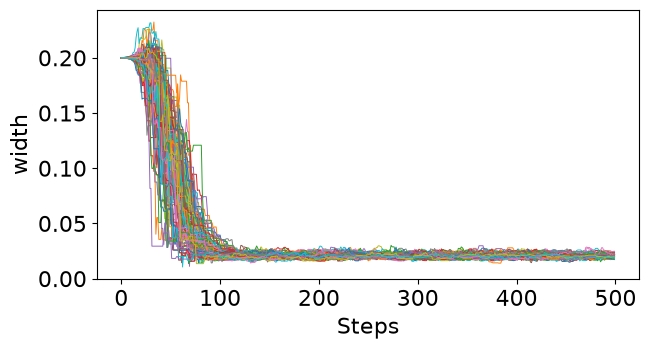

In [22]:
plotchains(emcee_result.chain, labels=['frac','pos','width'])

We see that it takes some number of steps for the parameters to settle down. This is called the "burn-in" phase. 

In this example, it looks like takes about 150 steps to burn in.

``emcee`` allows you to discard a burn-in phase.

In [23]:
# for emcee where we will *maximise*, so the function is just ln(post)
minim = lmfit.Minimizer(lnprob, params, fcn_args=((data,)),float_behavior='posterior')
emcee_result = minim.emcee(burn=250, steps=5000, thin=1, params=minim.params)

100%|████████████████████████████████████████| 5000/5000 [01:28<00:00, 56.56it/s]


Chain shape:  4750 steps, 100 walkers, 3 params.


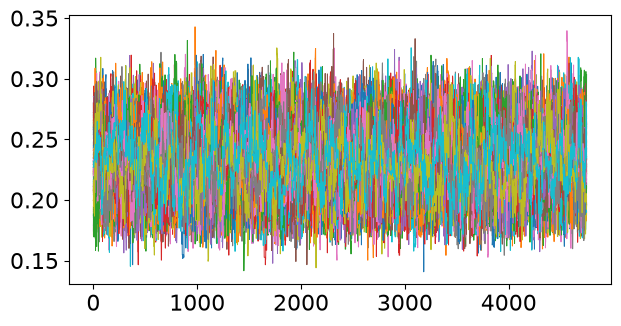

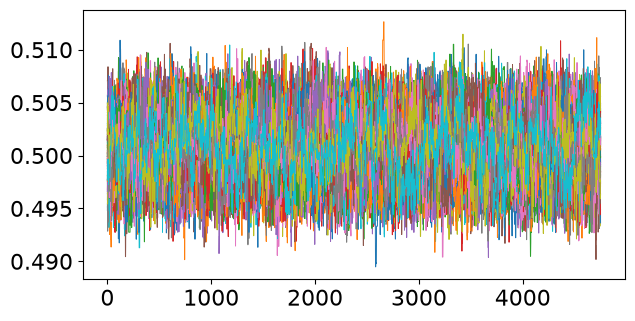

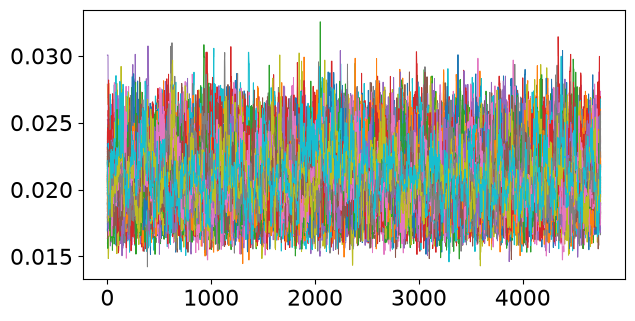

In [24]:
plotchains(emcee_result.chain)

Now the amazing thing is that the MCMC chains sample the probability distribution of the parameters!

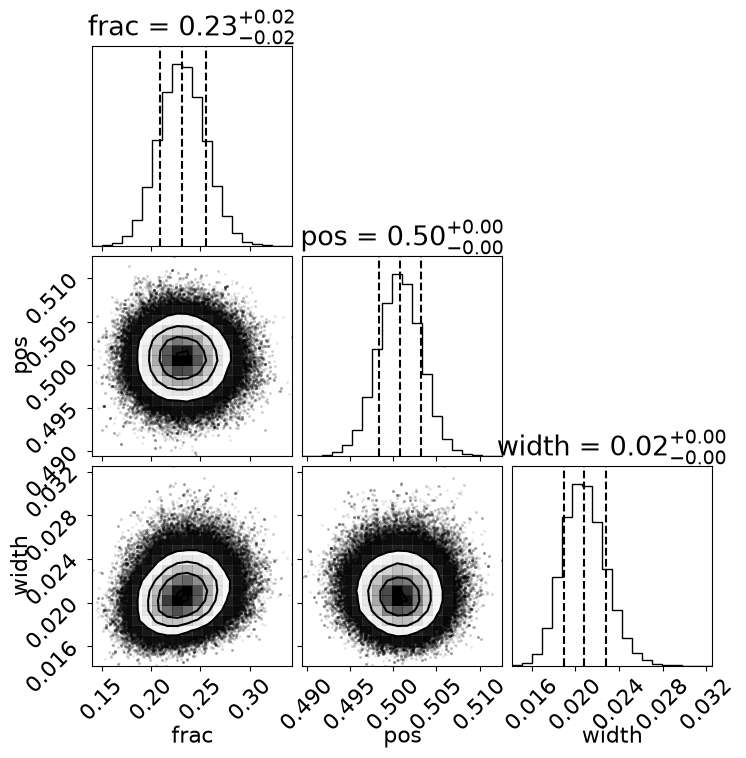

In [25]:
import corner
fig = corner.corner(emcee_result.flatchain, labels=emcee_result.var_names, 
                    quantiles=[0.16, 0.5, 0.84],show_titles=True)
                    #truths=list(emcee_result.params.valuesdict().values()))

In [26]:
quant = [0.16, 0.5, 0.84]
for param in ['frac', 'pos', 'width']:
    low, median, high = np.quantile(emcee_result.flatchain[param], quant)
    # mean = np.mean(emcee_result.flatchain[param])
    print(f'{param:10s} {median:10.4g} +{high-median:10.4g} -{median-low:1.4g}')


frac           0.2317 +   0.02349 -0.02267
pos            0.5008 +  0.002462 -0.002472
width         0.02077 +  0.002047 -0.001821
